# Exploration des données: Give Me Some Credit

Analyse exploratoire du dataset GMSC avant nettoyage et imputation.


In [10]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

from src.data.load import load_raw

df = load_raw()
df.shape

(150000, 11)

## Vue d'ensemble

In [11]:
print(f"Lignes : {df.shape[0]:,}")
print(f"Colonnes : {df.shape[1]}")
print(f"Taux de défaut : {df['SeriousDlqin2yrs'].mean() * 100:.2f} %")

Lignes : 150,000
Colonnes : 11
Taux de défaut : 6.68 %


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


## Répartition de la variable cible

In [13]:
target_counts = df["SeriousDlqin2yrs"].value_counts().rename({0: "Pas de défaut", 1: "Défaut"})

fig = px.bar(
    x=target_counts.index,
    y=target_counts.values,
    labels={"x": "Statut", "y": "Nombre de clients"},
    text=target_counts.values,
    title="Répartition de la cible",
)
fig.show()


## Valeurs manquantes

In [14]:
n_missing = df.isna().sum()
pct_missing = (n_missing / len(df) * 100).round(2)

report = (
    pd.DataFrame({"n_missing": n_missing, "pct_missing": pct_missing})
    .query("n_missing > 0")
    .sort_values("pct_missing", ascending=False)
)
display(report)

fig = px.bar(
    report,
    x=report.index,
    y="pct_missing",
    labels={"x": "Colonne", "pct_missing": "% manquant"},
    text="pct_missing",
    title="Pourcentage de valeurs manquantes par colonne",
)
fig.show()


,n_missing,pct_missing
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


In [16]:
print(f"Nombre de lignes avec age = 0 : {(df['age'] == 0).sum()}")

fig_hist = px.histogram(df, x="age", nbins=50, title="Distribution de age")
fig_hist.show()

fig_box = px.box(df, y="age", title="Boxplot de age")
fig_box.show()

Nombre de lignes avec age = 0 : 1


### Age = 0
Un âge de 0 est biologiquement impossible pour un emprunteur.

### Codes sentinelles 96/98

Les colonnes de retard de paiement contiennent des valeurs 96 et 98 qui apparaissent isolées, loin des valeurs normales (0-13). Ce sont des codes système, pas de vrais comptages.


NumberOfTime30-59DaysPastDueNotWorse : 269 valeurs suspectes (96/98)
NumberOfTime60-89DaysPastDueNotWorse : 269 valeurs suspectes (96/98)
NumberOfTimes90DaysLate : 269 valeurs suspectes (96/98)


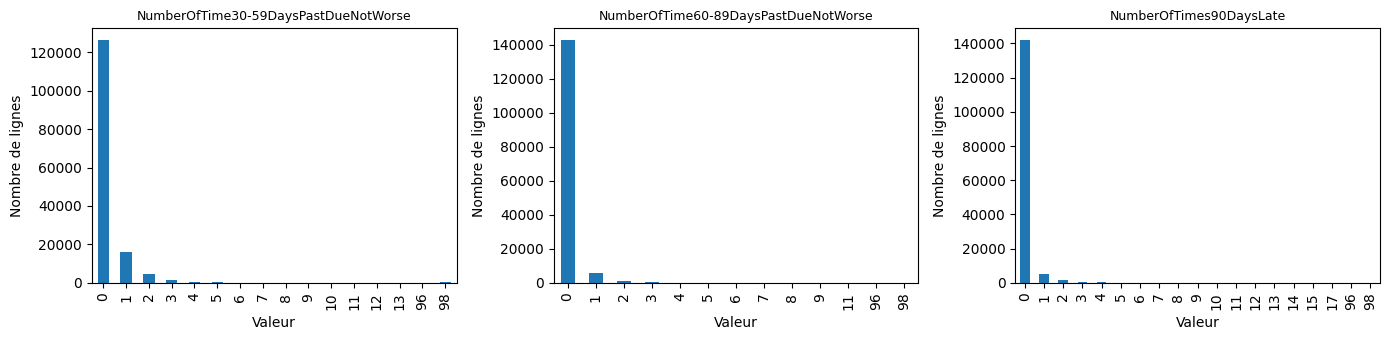

In [17]:
SENTINEL_COLUMNS = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

for col in SENTINEL_COLUMNS:
    n_sentinel = df[col].isin([96, 98]).sum()
    print(f"{col} : {n_sentinel} valeurs suspectes (96/98)")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for i, col in enumerate(SENTINEL_COLUMNS):
    df[col].value_counts().sort_index().plot(kind="bar", ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("Valeur")
    axes[i].set_ylabel("Nombre de lignes")
plt.tight_layout()
plt.show()
